# MACHINE LEARNING
# Basic Classification Systems

### Objectives

Compare the prediction error on a Breast Cancer dataset and a Prostate cancer dataset of:

- The Naive Bayes (NB) Classifier
- LDA
- QDA
- Nearest Shrunken Centroids (NSC) Classifier

> *Note:* To reduce the variance of the estimates, report average error results over 20 different partitions of the data into training and testing.

#### Loading required packages:

In [1]:
import numpy as np
import pandas as pd
# import scipy as sp
# import scipy.stats as stats
from scipy import linalg
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib as mpl
# from matplotlib import colors
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, RepeatedStratifiedKFold, GridSearchCV
from sklearn import preprocessing
from sklearn.metrics import accuracy_score, make_scorer, confusion_matrix, recall_score
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import NearestCentroid

# We ignore warnings (they arise in QDA due to the high dimensionality of the data)
import warnings
warnings.filterwarnings("ignore")

## Loading the Data

#### Breast dataset

We will examine the dataset for the **'Wisconsin Diagnostic Breast Cancer'**. For this we first read the [paper](https://minds.wisconsin.edu/bitstream/handle/1793/59692/TR1131.pdf;jsessionid=4B1DEBB3DEF492EA8213CB124F819481?sequence=1) so we can have an idea what the dataset is about.

This is followed by loading the data from a CSV file using pandas and observing what we have:

In [2]:
databreast = pd.read_csv('./wdbc.csv', header=None)

# Extracting the variables y and x:
# y = class label; C- = 0, C+ = 1
y_b = (databreast.values[ :, 1 ] == 'M').astype(int)

# x with the attributes: removing columns 1(ID) and 2(class label):
x_b = databreast.values[ :, 2:].astype(float)

print(databreast.shape)
print(y_b.shape)
print(x_b.shape)
databreast.head(-5)

(569, 32)
(569,)
(569, 30)


,0,1,2,3,4,5,6,7,8,9,...,22,23,24,25,26,27,28,29,30,31
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,25.38,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.26540,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,24.99,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.18600,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,23.57,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.24300,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,14.91,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.25750,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,22.54,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.16250,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
559,925291,B,11.51,23.93,74.52,403.5,0.09261,0.10210,0.11120,0.04105,...,12.48,37.16,82.28,474.2,0.12980,0.25170,0.3630,0.09653,0.2112,0.08732
560,925292,B,14.05,27.15,91.38,600.4,0.09929,0.11260,0.04462,0.04304,...,15.30,33.17,100.20,706.7,0.12410,0.22640,0.1326,0.10480,0.2250,0.08321
561,925311,B,11.20,29.37,70.67,386.0,0.07449,0.03558,0.00000,0.00000,...,11.92,38.30,75.19,439.6,0.09267,0.05494,0.0000,0.00000,0.1566,0.05905
562,925622,M,15.22,30.62,103.40,716.9,0.10480,0.20870,0.25500,0.09429,...,17.52,42.79,128.70,915.0,0.14170,0.79170,1.1700,0.23560,0.4089,0.14090


From the previous we can extract that:
- The task of interest is to predict whether or not a cell corresponds to a malignant tumor.
- In this dataset all attributes take real values.
- We will ignore the first attribute, which corresponds to the ID of each sample.
- We need to code B (benign) and M (malignant) into numerical data.


#### Prostate dataset

By reading the paper related to the ['Gene expression correlates of clinical prostate cancer behavior'](https://www.cell.com/cancer-cell/fulltext/S1535-6108(02)00030-2?_returnURL=https%3A%2F%2Flinkinghub.elsevier.com%2Fretrieve%2Fpii%2FS1535610802000302%3Fshowall%3Dtrue) we can see what are they dealing with in this data set.

Then we load and inspect the prostate dataset:

In [3]:
dataprostate = pd.read_csv('./prostate.csv')

# Extracting the variables y and x:
y = (dataprostate.values[ :, -1]).astype(int) # Taking the last column with the class labels
x = dataprostate.values[ :, :-1].astype(float) # Removing the last column

print(dataprostate.shape)
print(y.shape)
print(x.shape)
dataprostate.head(-5)

(102, 12626)
(102,)
(102, 12625)


,100_g_at,1000_at,1001_at,1002_f_at,1003_s_at,1004_at,1005_at,1006_at,1007_s_at,1008_f_at,...,AFFX-ThrX-5_at,AFFX-ThrX-M_at,AFFX-TrpnX-3_at,AFFX-TrpnX-5_at,AFFX-TrpnX-M_at,AFFX-YEL002c/WBP1_at,AFFX-YEL018w/_at,AFFX-YEL021w/URA3_at,AFFX-YEL024w/RIP1_at,Y
0,6.927460,7.391657,3.812922,3.453385,6.070151,5.527153,5.812353,3.167275,7.354981,9.419909,...,3.770583,2.884436,2.730025,3.126168,2.870161,3.082210,2.747289,3.226588,3.480196,0
1,7.222432,7.329050,3.958028,3.407226,5.921265,5.376464,7.303408,3.108708,7.391872,10.539579,...,3.190759,2.460119,2.696578,2.675271,2.940032,3.126269,3.013745,3.517859,3.428752,1
2,6.776402,7.664007,3.783702,3.152019,5.452293,5.111794,7.207638,3.077360,7.488371,6.833428,...,3.325183,2.603014,2.469759,2.615746,2.510172,2.730814,2.613696,2.823436,3.049716,0
3,6.919134,7.469634,4.004581,3.341170,6.070925,5.296108,8.744059,3.117104,7.203028,10.400557,...,3.625057,2.765521,2.681757,3.310741,3.197177,3.414182,3.193867,3.353537,3.567482,0
4,7.113561,7.322408,4.242724,3.489324,6.141657,5.628390,6.825370,3.794904,7.403024,10.240322,...,3.698067,3.026876,2.691670,3.236030,3.003906,3.081497,2.963307,3.472050,3.598103,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
92,7.063419,7.285983,3.854221,3.390404,6.247773,5.586135,5.321179,3.396357,6.990409,11.274830,...,3.661301,3.025382,2.772422,3.636103,3.031866,3.179024,3.201118,3.676463,3.659912,0
93,6.991399,7.314299,3.851756,3.451345,5.833395,5.280733,6.658825,3.346247,7.383300,9.942442,...,3.369860,2.604230,2.494963,3.105434,2.645753,2.768796,2.706012,3.410995,3.299711,1
94,6.921297,7.110933,4.030759,3.293485,5.966867,5.489405,7.729022,3.258396,7.562619,9.693181,...,3.498445,3.146484,2.751905,3.264817,2.802450,3.042133,2.963229,3.386644,3.569701,1
95,7.112788,7.111270,4.139401,3.546811,6.651695,5.750726,5.396859,3.662638,7.080457,11.413061,...,3.961689,3.248811,2.770429,3.932461,3.529736,3.228413,3.353272,4.019944,4.040468,1


From the collected information we can extract the following:
- We have 52 prostate tumors and 50 nontumor prostate samples, and approximately 12,600 genes (attributes).
- The task of interest is to distinguish nontumor from tumor samples, given the gene expression.
- All attributes take real values.
- We need to separate the last column, which corresponds to the class label.

Furthermore, we observe that the prostate dataset has fewer than 1/5 the number of entries (102 vs. 569) compared to the breast dataset. However, the prostate contains over 400 times as many features (12,626 vs. 30).

## Breast Dataset Data Prediction
Data Prediction with four different classifiers: NB, LDA, QDA and NSC.

 ### Method
 1. The average error is calculated over 20 different partitions of the data into training and testing. This is performed by removing the `random_state=1` parameter which fixes partitions and evaluating the models on the exact same data split.
 2. A log of the run is created, containing the calculation of the precision and hyperparameter (if applicable) for each iteration.

In [6]:
# Function to calculate metrics
def calculate_metrics(y_true, y_pred):
    """Calculate metrics from confusion matrix"""
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    accuracy = (tp + tn) / (tp + tn + fp + fn)
    tpr = tp / (tp + fn)  # Sensitivity/Recall
    tnr = tn / (tn + fp)  # Specificity
    return accuracy, tpr, tnr

# Define variables for the log.txt file
contenido = ''
contenido_nb = 'Iteration \t Method \t Accuracy\n'
contenido_lda = 'Iteration \t Method \t Accuracy\n'
contenido_qda = 'Iteration \t Method \t Accuracy \t Hyperparameter\n'
contenido_nsc = 'Iteration \t Method \t Accuracy \t Hyperparameter\n'

# Initialize lists to store metrics (accuracy, TPR, TNR) and hyperparameters
metrics_nb = []
metrics_lda = []
metrics_qda = []
metrics_nsc = []

reg_param_qda_breast = []
shrink_thres_nsc = []

index = 0

for rep in range(20):
    index += 1

    # Train/test split
    x_btrain, x_btest, y_btrain, y_btest = train_test_split(x_b, y_b, test_size=1/3)

    # Data preprocessing
    scaler = preprocessing.StandardScaler().fit(x_btrain)
    x_btrain_scaled = scaler.transform(x_btrain)
    x_btest_scaled = scaler.transform(x_btest)

    ####### Naive Bayes #######################################################
    nb_b = GaussianNB().fit(x_btrain_scaled, y_btrain)
    y_pred_nb = nb_b.predict(x_btest_scaled)
    metrics_nb.append(calculate_metrics(y_btest, y_pred_nb))
    contenido_nb += (
      f"{index} \t\t Naive Bayes \t {round(calculate_metrics(y_btest, y_pred_nb)[0],3)}\n")

    ####### LDA ###############################################################
    lda_b = LinearDiscriminantAnalysis().fit(x_btrain_scaled, y_btrain)
    y_pred_lda = lda_b.predict(x_btest_scaled)
    metrics_lda.append(calculate_metrics(y_btest, y_pred_lda))
    contenido_lda += (
      f"{index} \t\t LDA \t\t {round(calculate_metrics(y_btest, y_pred_lda)[0],3)}\n")

    ####### QDA ###############################################################
    pipeline_qda = Pipeline([('qda', QuadraticDiscriminantAnalysis())])
    param_grid = {'qda__reg_param': np.linspace(0, 1, 10)}

    gridcv_QDAbreast = GridSearchCV(pipeline_qda, param_grid=param_grid,
                                  cv=RepeatedStratifiedKFold(n_splits=10, n_repeats=1, random_state=0),
                                  scoring=make_scorer(accuracy_score))
    gridcv_QDAbreast.fit(x_btrain_scaled, y_btrain)

    best_qda = gridcv_QDAbreast.best_estimator_
    y_pred_qda = best_qda.predict(x_btest_scaled)
    metrics_qda.append(calculate_metrics(y_btest, y_pred_qda))
    reg_param_qda_breast.append(gridcv_QDAbreast.best_params_['qda__reg_param'])
    contenido_qda += (
      f"{index} \t\t QDA \t\t {round(calculate_metrics(y_btest, y_pred_qda)[0],3)}\t\t "
      f"{round(gridcv_QDAbreast.best_params_['qda__reg_param'],3)}\n")

    ####### NSC ###############################################################
    pipeline_nsc = Pipeline([('nsc', NearestCentroid())])
    param_grid_nsc = {'nsc__shrink_threshold': np.linspace(1e-6, 8, 20)}

    gridcv_NCSbreast = GridSearchCV(pipeline_nsc, param_grid=param_grid_nsc,
                                  cv=RepeatedStratifiedKFold(n_splits=10,
                                            n_repeats=1, random_state=0),
                                  scoring=make_scorer(accuracy_score))
    gridcv_NCSbreast.fit(x_btrain_scaled, y_btrain)

    best_nsc = gridcv_NCSbreast.best_estimator_
    y_pred_nsc = best_nsc.predict(x_btest_scaled)
    metrics_nsc.append(calculate_metrics(y_btest, y_pred_nsc))
    shrink_thres_nsc.append(gridcv_NCSbreast.best_params_['nsc__shrink_threshold'])
    contenido_nsc += (
      f"{index} \t\t NSC \t\t {round(calculate_metrics(y_btest, y_pred_nsc)[0],3)}\t\t "
      f"{round(gridcv_NCSbreast.best_params_['nsc__shrink_threshold'],3)}\n")

# Insert content into text variable
contenido += "\n--------------------------------------------------------------------------\n"
contenido += 'For the breast cancer dataset we have the following results:'
contenido += "\n--------------------------------------------------------------------------\n"
contenido += contenido_nb + '\n' + contenido_lda + '\n' + contenido_qda + '\n' + contenido_nsc

with open ('log.txt', 'w') as f:
  f.write(contenido + "\n")
# print(contenido)

print(f"""
The accuracies and hyperparameters resulting from each run of the classifier
on the breast cancer dataset have been logged into >> log.txt""")


The accuracies and hyperparameters resulting from each run of the classifier 
on the breast cancer dataset have been logged into >> log.txt


### Results

Lets observe the performance per run of each classifier on the breast dataset.

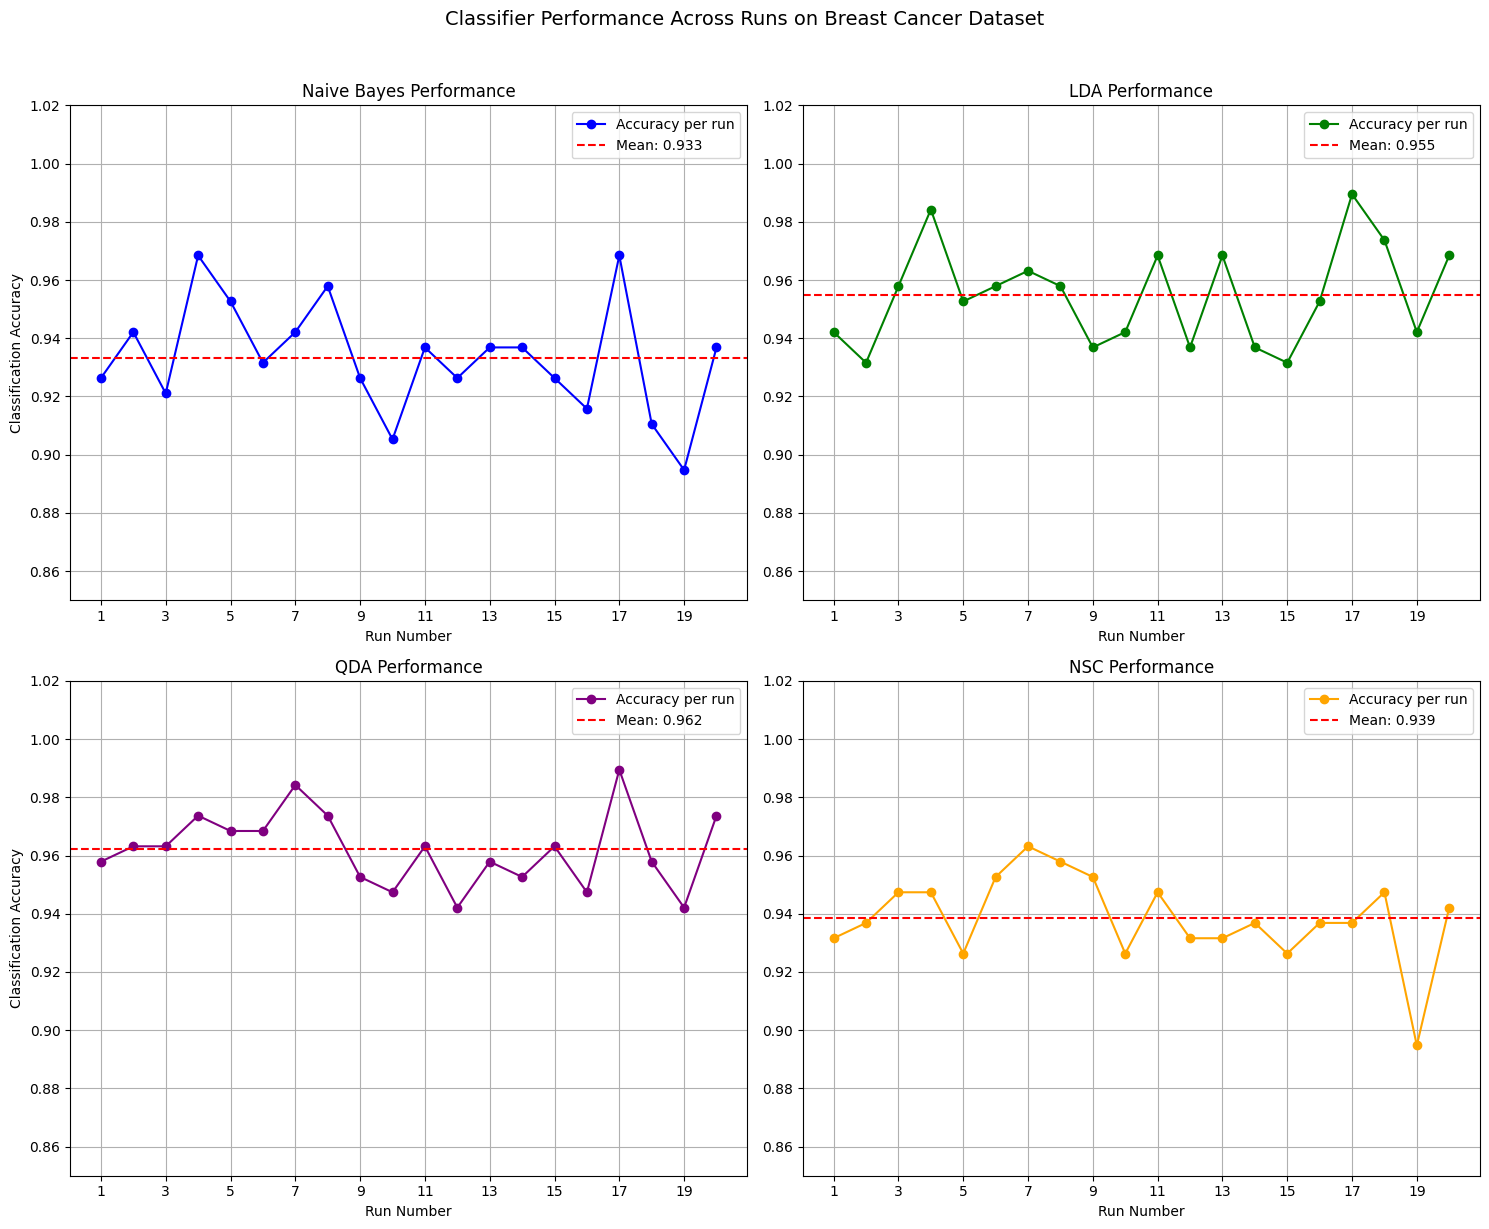

In [7]:
# Create figure with 4 subplots
f, axarr = plt.subplots(2, 2, figsize=(15, 12))

# Adjust spacing between subplots
plt.subplots_adjust(hspace=0.3, wspace=0.3)

# Create x-axis values (run numbers) - use length of metrics list
run_numbers = np.arange(1, len(metrics_nb)+1)

# Extract accuracy values from metrics
acc_nb = [m[0] for m in metrics_nb]  # Get accuracy (first element) from each tuple
acc_lda = [m[0] for m in metrics_lda]
acc_qda = [m[0] for m in metrics_qda]
acc_nsc = [m[0] for m in metrics_nsc]

# Calculate means of accuracy values
mean_nb = np.mean(acc_nb)
mean_lda = np.mean(acc_lda)
mean_qda = np.mean(acc_qda)
mean_nsc = np.mean(acc_nsc)

# First subplot: NB results
axarr[0,0].plot(run_numbers, acc_nb, 'o-', color='blue', label='Accuracy per run')
axarr[0,0].axhline(mean_nb, color='red', linestyle='--',
                  label=f'Mean: {mean_nb:.3f}')
axarr[0,0].set_title("Naive Bayes Performance")
axarr[0,0].set_xlabel('Run Number')
axarr[0,0].set_ylabel('Classification Accuracy')
axarr[0,0].set_ylim((0.85, 1.02))
axarr[0,0].set_xticks(run_numbers[::2])  # Show every other run number
axarr[0,0].grid(True)
axarr[0,0].legend()

# Second subplot: LDA results
axarr[0,1].plot(run_numbers, acc_lda, 'o-', color='green', label='Accuracy per run')
axarr[0,1].axhline(mean_lda, color='red', linestyle='--',
                  label=f'Mean: {mean_lda:.3f}')
axarr[0,1].set_title("LDA Performance")
axarr[0,1].set_xlabel('Run Number')
axarr[0,1].set_ylim((0.85, 1.02))
axarr[0,1].set_xticks(run_numbers[::2])
axarr[0,1].grid(True)
axarr[0,1].legend()

# Third subplot: QDA results
axarr[1,0].plot(run_numbers, acc_qda, 'o-', color='purple', label='Accuracy per run')
axarr[1,0].axhline(mean_qda, color='red', linestyle='--',
                  label=f'Mean: {mean_qda:.3f}')
axarr[1,0].set_title("QDA Performance")
axarr[1,0].set_xlabel('Run Number')
axarr[1,0].set_ylabel('Classification Accuracy')
axarr[1,0].set_ylim((0.85, 1.02))
axarr[1,0].set_xticks(run_numbers[::2])
axarr[1,0].grid(True)
axarr[1,0].legend()

# Fourth subplot: NSC results
axarr[1,1].plot(run_numbers, acc_nsc, 'o-', color='orange', label='Accuracy per run')
axarr[1,1].axhline(mean_nsc, color='red', linestyle='--',
                  label=f'Mean: {mean_nsc:.3f}')
axarr[1,1].set_title("NSC Performance")
axarr[1,1].set_xlabel('Run Number')
axarr[1,1].set_ylim((0.85, 1.02))
axarr[1,1].set_xticks(run_numbers[::2])
axarr[1,1].grid(True)
axarr[1,1].legend()

# Add overall title
plt.suptitle("Classifier Performance Across Runs on Breast Cancer Dataset", y=1.02, fontsize=14)

# Adjust layout and show
plt.tight_layout()
plt.show()

Now lets make a breakdown of the results obtained:

In [10]:
# Calculate mean metrics (per column: accuracy, TPR, TNR)
mean_nb = np.mean(metrics_nb, axis=0)
mean_lda = np.mean(metrics_lda, axis=0)
mean_qda = np.mean(metrics_qda, axis=0)
mean_nsc = np.mean(metrics_nsc, axis=0)

# Create results table
results = pd.DataFrame({
    'NB': mean_nb,
    'LDA': mean_lda,
    'QDA': mean_qda,
    'NSC': mean_nsc
}, index=['Accuracy', 'TPR', 'TNR']).T.round(6)

print("\nClassifiers Performance Metrics:")
print("=" * 100)
print(results)
print("\n" + "-" * 100)
print("* TPR (True Positive Rate/Sensitivity): Proportion of actual positives correctly identified")
print("** TNR (True Negative Rate/Specificity): Proportion of actual negatives correctly identified")
print("-" * 100)


Classifiers Performance Metrics:
     Accuracy       TPR       TNR
NB   0.933158  0.893401  0.955678
LDA  0.954737  0.888755  0.992286
QDA  0.962105  0.921065  0.985472
NSC  0.938684  0.898844  0.961051

----------------------------------------------------------------------------------------------------
* TPR (True Positive Rate/Sensitivity): Proportion of actual positives correctly identified
** TNR (True Negative Rate/Specificity): Proportion of actual negatives correctly identified
----------------------------------------------------------------------------------------------------


### Conclusions
**What method performs best in terms of prediction error?**
- We can observe that the best accuracy results are obtained by Quadratic Discriminant Analysis (QDA) and Linear Discriminant Analysis (LDA). Being QDA the overall best classifier with an accuracy \~ 96%.
- QDA and LDA are undoubtedly better predictors than Naive Bayes (NB) because NB assumes independent features, something which is not the best approach here since tumor radius and texture are correlated, for example.
- QDA and LDA also perform better than Nearest Shrunken Centroids (NSC). Since NSC treats all features as independent when computing distances, it is just comparing distances to class means and ignoring feature interactions. Whilst, QDA and LDA account for these correlations (via covariance matrices).

**What method is more flexible according to what we have seen in the lectures? Is this compatible with the obtained results?**

The most flexible method is QDA, because it has more parameters that we can adjust. This causes that this method is also the most prone to over-fitting.

In fact QDA yielded a TPR (Sensitivity) of aproximately \~ 92% and a TNR (Specificity) around \~ 98%. Which indicates that this dataset is relatively balanced, and QDA handles both positive and negative classes well, showing to be more flexible.

**What method is more robust to over-fitting according to what we have seen in the lectures? Is this compatible with the obtained results?**

Despite the fact that this dataset is not extremely high-dimensional, since we observe a moderate feature to sample ratio (32 features / 569 samples ~ 1:18), QDA avoids overfitting by tuning the `reg_param` through the GridSearchCV. Whilst LDA, being simpler, may underfit with the shared covariance.

## Prostate Dataset Data Prediction
Data Prediction with four different classifiers: NB, LDA, QDA and NSC.

### Method

In [12]:
def calculate_metrics(y_true, y_pred):
    """Calculate metrics from confusion matrix"""
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    accuracy = (tp + tn) / (tp + tn + fp + fn)
    tpr = tp / (tp + fn)  # Sensitivity/Recall
    tnr = tn / (tn + fp)  # Specificity
    return accuracy, tpr, tnr

# Define variables for the log.txt file
contenido_prost = ''
contenido_prost_nb = 'Iteration \t Method \t Accuracy\n'
contenido_prost_lda = 'Iteration \t Method \t Accuracy\n'
contenido_prost_qda = 'Iteration \t Method \t Accuracy \t Hyperparameter\n'
contenido_prost_nsc = 'Iteration \t Method \t Accuracy \t Hyperparameter\n'

# Initialize lists to store metrics (accuracy, TPR, TNR) and hyperparameters
metrics_p_nb = []
metrics_p_lda = []
metrics_p_qda = []
metrics_p_nsc = []

reg_param_qda_prost = []
shrink_thres_nsc_prost = []

index = 0

for rep in range(20):
    index += 1

    # Train/test split
    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=1/3)

    # Data preprocessing
    scaler = preprocessing.StandardScaler().fit(x_train)
    x_train_scaled = scaler.transform(x_train)
    x_test_scaled = scaler.transform(x_test)

    ####### Naive Bayes #######################################################
    nb = GaussianNB().fit(x_train_scaled, y_train)
    y_pred_nb = nb.predict(x_test_scaled)
    metrics_p_nb.append(calculate_metrics(y_test, y_pred_nb))
    contenido_prost_nb += (
      f'{index} \t\t Naive Bayes \t {round(calculate_metrics(y_test, y_pred_nb)[0],3)}\n')

    ####### LDA ###############################################################
    lda = LinearDiscriminantAnalysis().fit(x_train_scaled, y_train)
    y_pred_lda = lda.predict(x_test_scaled)
    metrics_p_lda.append(calculate_metrics(y_test, y_pred_lda))
    contenido_prost_lda += (
      f'{index} \t\t LDA \t\t {round(calculate_metrics(y_test, y_pred_lda)[0],3)}\n')

    ####### QDA ###############################################################
    pipeline_qda_prostate = Pipeline([('qda', QuadraticDiscriminantAnalysis())])
    param_grid_prostate = {'qda__reg_param': np.linspace(0, 1, 10)}

    gridcv_QDAprostate = GridSearchCV(
        pipeline_qda_prostate,
        param_grid=param_grid_prostate,
        cv=RepeatedStratifiedKFold(n_splits=10, n_repeats=1, random_state=0),
        scoring=make_scorer(accuracy_score)
    )
    gridcv_QDAprostate.fit(x_train_scaled, y_train)

    best_qda_prostate = gridcv_QDAprostate.best_estimator_
    y_pred_qda_prostate = best_qda_prostate.predict(x_test_scaled)
    metrics_p_qda.append(calculate_metrics(y_test, y_pred_qda_prostate))
    reg_param_qda_prost.append(gridcv_QDAprostate.best_params_['qda__reg_param'])
    contenido_prost_qda += (
      f"{index} \t\t QDA \t\t {round(calculate_metrics(y_test, y_pred_qda_prostate)[0],3)}\t\t "
      f"{round(gridcv_QDAprostate.best_params_['qda__reg_param'],3)}\n")

    ####### NSC ###############################################################
    pipeline_nsc_prostate = Pipeline([('nsc', NearestCentroid())])
    param_grid_nsc_prostate = {'nsc__shrink_threshold': np.linspace(1e-6, 8, 20)}

    gridcv_NCSprostate = GridSearchCV(
        pipeline_nsc_prostate,
        param_grid=param_grid_nsc_prostate,
        cv=RepeatedStratifiedKFold(n_splits=10, n_repeats=1, random_state=0),
        scoring=make_scorer(accuracy_score)
    )
    gridcv_NCSprostate.fit(x_train_scaled, y_train)

    best_nsc_prostate = gridcv_NCSprostate.best_estimator_
    y_pred_nsc_prostate = best_nsc_prostate.predict(x_test_scaled)
    metrics_p_nsc.append(calculate_metrics(y_test, y_pred_nsc_prostate))
    shrink_thres_nsc_prost.append(gridcv_NCSprostate.best_params_['nsc__shrink_threshold'])

    contenido_prost_nsc += (
        f"{index} \t\t NSC \t\t {round(calculate_metrics(y_test, y_pred_nsc_prostate)[0],3)}\t\t "
        f"{round(gridcv_NCSprostate.best_params_['nsc__shrink_threshold'],3)}\n"
    )

contenido_prost += "\n\n--------------------------------------------------------------------------\n"
contenido_prost += 'For the prostate cancer dataset we have the following results:\n'
contenido_prost += "\n--------------------------------------------------------------------------\n"
contenido_prost += contenido_prost_nb + '\n' + contenido_prost_lda + '\n' + contenido_prost_qda + '\n' + contenido_prost_nsc


with open ('log.txt', 'a') as f:
  f.write(contenido_prost + "\n")

print(f"The accuracies and hyperparameters resulting from each run of the classifier on the prostate cancer dataset have been logged into >> log.txt")

The accuracies and hyperparameters resulting from each run of the classifier on the prostate cancer dataset have been logged into >> log.txt


### Results

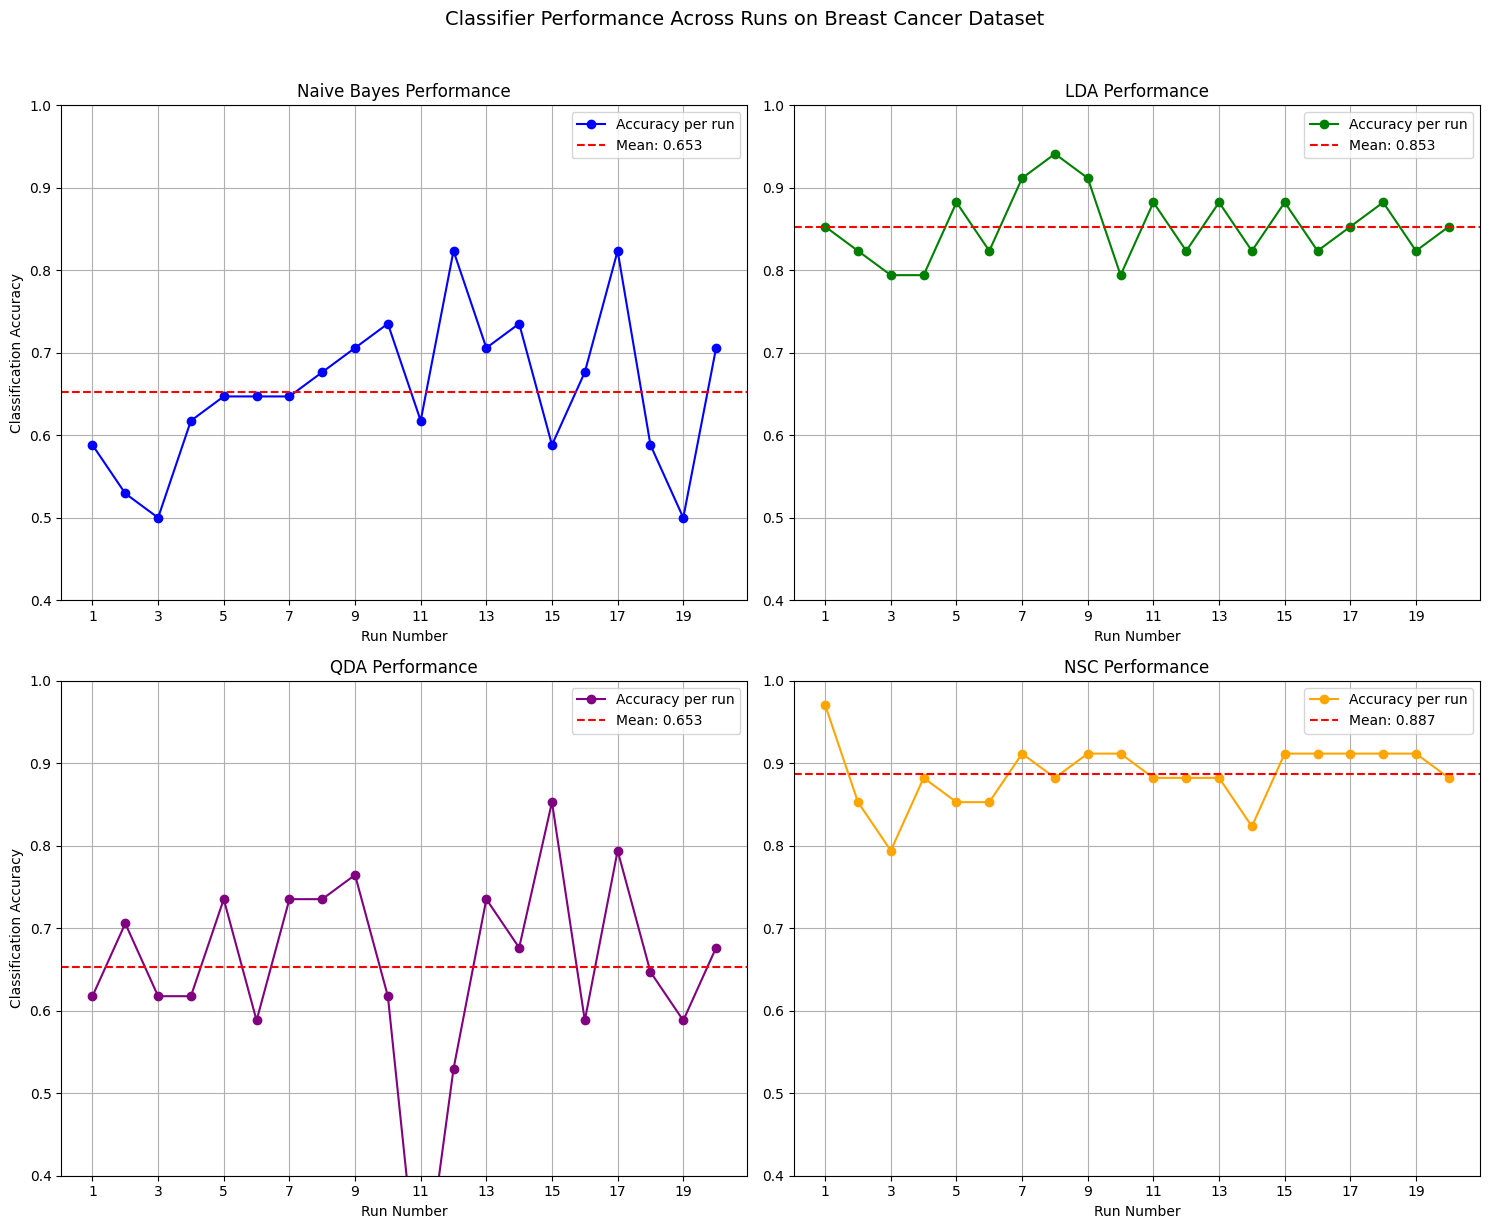

In [15]:
# Create figure with 4 subplots
f, axarr = plt.subplots(2, 2, figsize=(15, 12))

# Adjust spacing between subplots
plt.subplots_adjust(hspace=0.3, wspace=0.3)

# Create x-axis values (run numbers) - use length of metrics list
run_numbers = np.arange(1, len(metrics_p_nb)+1)

# Extract accuracy values from metrics
acc_p_nb = [m[0] for m in metrics_p_nb]  # Get accuracy (first element) from each tuple
acc_p_lda = [m[0] for m in metrics_p_lda]
acc_p_qda = [m[0] for m in metrics_p_qda]
acc_p_nsc = [m[0] for m in metrics_p_nsc]

# Calculate means of accuracy values
mean_p_nb = np.mean(acc_p_nb)
mean_p_lda = np.mean(acc_p_lda)
mean_p_qda = np.mean(acc_p_qda)
mean_p_nsc = np.mean(acc_p_nsc)

# First subplot: NB results
axarr[0,0].plot(run_numbers, acc_p_nb, 'o-', color='blue', label='Accuracy per run')
axarr[0,0].axhline(mean_p_nb, color='red', linestyle='--',
                  label=f'Mean: {mean_p_nb:.3f}')
axarr[0,0].set_title("Naive Bayes Performance")
axarr[0,0].set_xlabel('Run Number')
axarr[0,0].set_ylabel('Classification Accuracy')
axarr[0,0].set_ylim((0.4,1))
axarr[0,0].set_xticks(run_numbers[::2])  # Show every other run number
axarr[0,0].grid(True)
axarr[0,0].legend()

# Second subplot: LDA results
axarr[0,1].plot(run_numbers, acc_p_lda, 'o-', color='green', label='Accuracy per run')
axarr[0,1].axhline(mean_p_lda, color='red', linestyle='--',
                  label=f'Mean: {mean_p_lda:.3f}')
axarr[0,1].set_title("LDA Performance")
axarr[0,1].set_xlabel('Run Number')
axarr[0,1].set_xticks(run_numbers[::2])
axarr[0,1].set_ylim((0.4,1))
axarr[0,1].grid(True)
axarr[0,1].legend()

# Third subplot: QDA results
axarr[1,0].plot(run_numbers, acc_p_qda, 'o-', color='purple', label='Accuracy per run')
axarr[1,0].axhline(mean_p_qda, color='red', linestyle='--',
                  label=f'Mean: {mean_p_qda:.3f}')
axarr[1,0].set_title("QDA Performance")
axarr[1,0].set_xlabel('Run Number')
axarr[1,0].set_ylabel('Classification Accuracy')
axarr[1,0].set_ylim((0.4,1))
axarr[1,0].set_xticks(run_numbers[::2])
axarr[1,0].grid(True)
axarr[1,0].legend()

# Fourth subplot: NSC results
axarr[1,1].plot(run_numbers, acc_p_nsc, 'o-', color='orange', label='Accuracy per run')
axarr[1,1].axhline(mean_p_nsc, color='red', linestyle='--',
                  label=f'Mean: {mean_p_nsc:.3f}')
axarr[1,1].set_title("NSC Performance")
axarr[1,1].set_xlabel('Run Number')
axarr[1,1].set_xticks(run_numbers[::2])
axarr[1,1].set_ylim((0.4,1))
axarr[1,1].grid(True)
axarr[1,1].legend()

# Add overall title
plt.suptitle("Classifier Performance Across Runs on Breast Cancer Dataset", y=1.02, fontsize=14)

# Adjust layout and show
plt.tight_layout()
plt.show()

In [ ]:
# Create and display results table
results = pd.DataFrame({
    'NB': mean_p_nb,
    'LDA': mean_p_lda,
    'QDA': mean_p_qda,
    'NSC': mean_p_nsc
}, index=['Accuracy', 'TPR', 'TNR']).T.round(6)

print("Classifiers Performance Metrics:")
print("="*100)
print(results)
print("\n" + "-"*100)
print("* TPR (True Positive Rate/Sensitivity): Proportion of actual positives correctly identified")
print("** TNR (True Negative Rate/Specificity): Proportion of actual negatives correctly identified")
print("-"*100)

Classifiers Performance Metrics:
     Accuracy       TPR       TNR
NB   0.602941  0.602941  0.602941
LDA  0.848529  0.848529  0.848529
QDA  0.641176  0.641176  0.641176
NSC  0.883824  0.883824  0.883824

----------------------------------------------------------------------------------------------------
* TPR (True Positive Rate/Sensitivity): Proportion of actual positives correctly identified
** TNR (True Negative Rate/Specificity): Proportion of actual negatives correctly identified
----------------------------------------------------------------------------------------------------


### Conclusions
**What method performs best in terms of prediction error?**

In this case, the best performing classifier is NSC (\~ 88% accuracy) and LDA (\~ 84% accuracy). NSC has the better performance due to the shrinkage of uninformative features (genes), which makes the classification problem to have smaller dimension. LDA has good performance due to the assumption of a common covariance between classes, which represents realistic correlations between genes. Despite being less flexible is more robust to over-fitting.

Naive Bayes does not work well because of its assumption of independent data, which is not plausible with 12600 genes. QDA calculates different covariance matrices for each class, and overfits with high dimensional data as in this case. As we can see in the irregularities observed in the graphic representation.


**What method is more flexible according to what we have seen in the lectures? Is this compatible with the obtained results?**

The most flexible method is QDA, because it has more parameters that we can adjust. This causes that this method is also the most prone to over-fitting, which is what happens in this dataset, yielding a lower accuracy.


**What method is more robust to over-fitting according to what we have seen in the lectures? Is this compatible with the obtained results?**

The most robust method to over-fitting would be Naive Bayes if variables were independent, which is not the case. In this scenario, the best method is NCS, because in this case reducing dimensionality discards non informative genes, which may be reducing noise and over-fitting. Also, the number of parameters to estimate is much less than LDA or QDA, which needs to calculate covariance matrices.


**Discuss and compare, regarding the bias and the variance, the procedure used to estimate the generalization error of a classifier trained on the available data with 10-fold-cross validation and leave-one-out cross-validation. Which one has a bigger bias and a bigger variance? Explain your response. You need not carry out additional experiments, only explain what you should expect to obtain according to what you have seen in the lectures.**

10-fold-cross validation consist in patitioning the data into ten different sets of the same size and training the machine learning algorithm into nine of ten different times using different sets each time and leave-one-out cross-validation consists in using all the data except one datum to train the model and using the only datum not used to train the model to see the error.

The bias is the capacity of a method to estimate the generalization error. In the case of the 10-fold-cross validation method, this has a higher bias compared to the leave-one-out cross-validation due to the fact that it uses only 90% of the dataset, which can ignore complex relationships that can only be obtained using the entire dataset.

The variance, in the other hand, refers to the variance of the estimation of the generalization method. This is higher for the leave-one-out procedure due to the fact that this is using only one datum, which can be very variable or even a outlier, while the 10-fold-cross validation uses several data and averages different choices of data.